In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [2]:
# Training and testing data
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv")["Disease"]
y_test = pd.read_csv("../data/y_test.csv")["Disease"]

# Model comparison
model_comparison = pd.read_csv("../data/model_comparison.csv")

# Feature sets
import json
with open("../data/feature_sets.json", "r") as f:
    feature_sets = json.load(f)

In [3]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nFeature sets:")
for name, features in feature_sets.items():
    print(f"{name}: {len(features)} features")

X_train: (104, 131)
X_test : (27, 131)
y_train: (104,)
y_test : (27,)

Feature sets:
All: 131 features
RF10: 10 features
RF20: 20 features
RF30: 30 features
RF50: 50 features
LASSO: 8 features
Consensus: 5 features


In [5]:
model_comparison.sort_values("ROC-AUC", ascending=False)

,Feature Set,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,RF10,Random Forest,0.666667,0.727273,0.571429,0.640000,0.785714
1,RF50,Random Forest,0.703704,0.800000,0.571429,0.666667,0.719780
2,Consensus,SVM,0.555556,0.666667,0.285714,0.400000,0.708791
3,All,Random Forest,0.740741,0.818182,0.642857,0.720000,0.686813
4,RF20,Random Forest,0.666667,0.727273,0.571429,0.640000,0.686813
5,RF30,Random Forest,0.666667,0.727273,0.571429,0.640000,0.686813
6,All,SVM,0.629630,0.666667,0.571429,0.615385,0.684066
7,RF10,Gradient Boosting,0.666667,0.777778,0.500000,0.608696,0.681319
8,LASSO,Gradient Boosting,0.555556,0.583333,0.500000,0.538462,0.675824
9,Consensus,Gradient Boosting,0.629630,0.700000,0.500000,0.583333,0.673077


In [6]:
model_comparison.sort_values(
    "ROC-AUC",
    ascending=False
)

,Feature Set,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,RF10,Random Forest,0.666667,0.727273,0.571429,0.640000,0.785714
1,RF50,Random Forest,0.703704,0.800000,0.571429,0.666667,0.719780
2,Consensus,SVM,0.555556,0.666667,0.285714,0.400000,0.708791
3,All,Random Forest,0.740741,0.818182,0.642857,0.720000,0.686813
4,RF20,Random Forest,0.666667,0.727273,0.571429,0.640000,0.686813
5,RF30,Random Forest,0.666667,0.727273,0.571429,0.640000,0.686813
6,All,SVM,0.629630,0.666667,0.571429,0.615385,0.684066
7,RF10,Gradient Boosting,0.666667,0.777778,0.500000,0.608696,0.681319
8,LASSO,Gradient Boosting,0.555556,0.583333,0.500000,0.538462,0.675824
9,Consensus,Gradient Boosting,0.629630,0.700000,0.500000,0.583333,0.673077


In [4]:
#prepare the data

features = feature_sets["RF10"]

Xtr = X_train[features]
Xte = X_test[features]

In [5]:
#hyperparameter tuning 

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(Xtr, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple m

Best parameters

In [6]:
print("Best parameters:")
print(grid.best_params_)

print("\nBest CV ROC-AUC:")
print(grid.best_score_)

Best parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}

Best CV ROC-AUC:
0.7149090909090908


In [7]:
#Evaluate on the test set

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

best_rf = grid.best_estimator_

pred = best_rf.predict(Xte)
prob = best_rf.predict_proba(Xte)[:, 1]

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1       :", f1_score(y_test, pred))
print("ROC-AUC  :", roc_auc_score(y_test, prob))

Accuracy : 0.7037037037037037
Precision: 0.75
Recall   : 0.6428571428571429
F1       : 0.6923076923076923
ROC-AUC  : 0.7362637362637363


<Figure size 600x600 with 0 Axes>

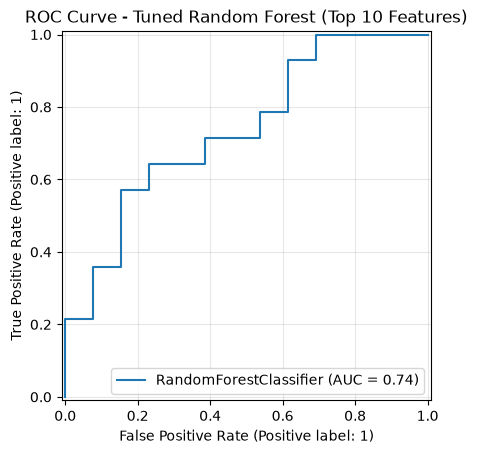

In [8]:
#ROC Curve
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(6, 6))

RocCurveDisplay.from_estimator(
    best_rf,
    Xte,
    y_test
)

plt.title("ROC Curve - Tuned Random Forest (Top 10 Features)")
plt.grid(alpha=0.3)
plt.show()

<Figure size 500x500 with 0 Axes>

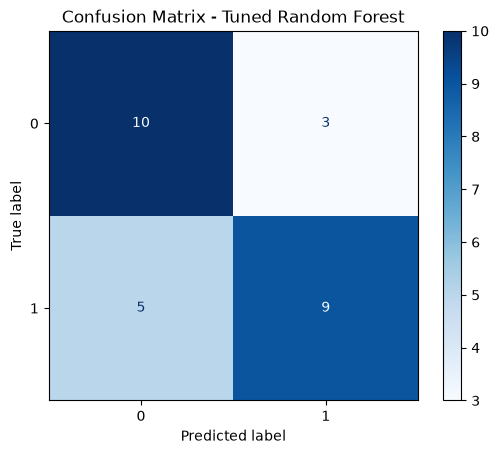

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(5, 5))

ConfusionMatrixDisplay.from_estimator(
    best_rf,
    Xte,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

<Figure size 500x500 with 0 Axes>

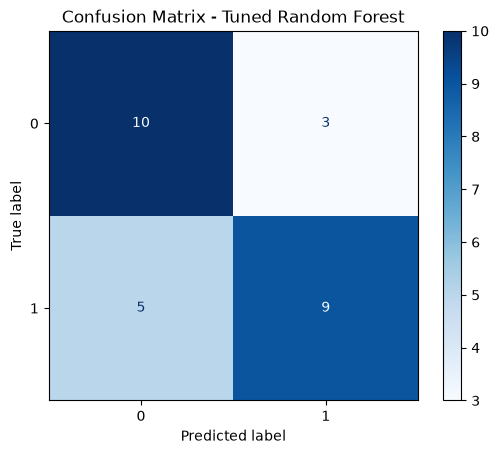

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(5, 5))

ConfusionMatrixDisplay.from_estimator(
    best_rf,
    Xte,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Tuned Random Forest")
fig = plt.gcf()
fig.savefig("../figures/tuned_rf_confusion_matrix.png", dpi=600, bbox_inches="tight")

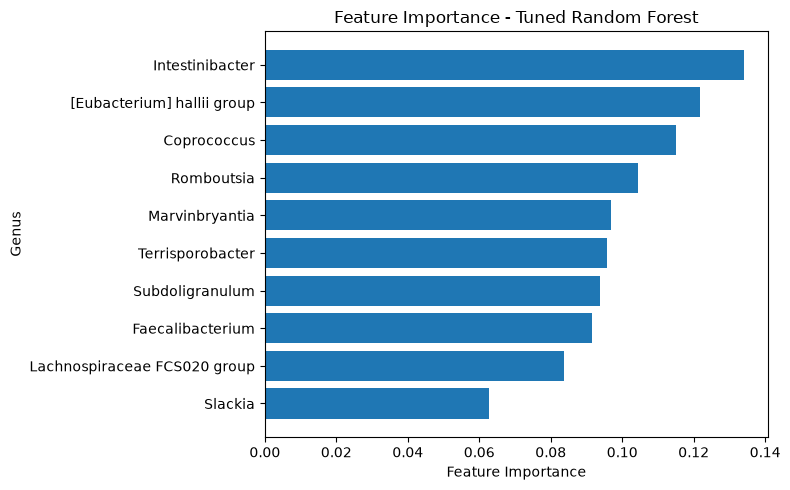

,Genus,Importance
1,Intestinibacter,0.134116
3,[Eubacterium] hallii group,0.121739
9,Coprococcus,0.115025
4,Romboutsia,0.104359
2,Marvinbryantia,0.096821
0,Terrisporobacter,0.095862
7,Subdoligranulum,0.093902
6,Faecalibacterium,0.091568
5,Lachnospiraceae FCS020 group,0.083825
8,Slackia,0.062784


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Genus": Xtr.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.barh(
    importance["Genus"],
    importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Genus")
plt.title("Feature Importance - Tuned Random Forest")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importance

In [17]:
#Save the feature importance
importance.to_csv(
    "../data/tuned_rf_feature_importance.csv",
    index=False
)


In [18]:
best_params = pd.DataFrame([grid.best_params_])

best_params.to_csv(
    "../data/best_rf_parameters.csv",
    index=False
)

best_params

,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators
0,5,sqrt,4,2,100


In [19]:
metrics = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, pred)],
    "Precision": [precision_score(y_test, pred)],
    "Recall": [recall_score(y_test, pred)],
    "F1": [f1_score(y_test, pred)],
    "ROC_AUC": [roc_auc_score(y_test, prob)]
})

metrics.to_csv(
    "../data/final_model_metrics.csv",
    index=False
)

metrics

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.703704,0.75,0.642857,0.692308,0.736264


In [20]:
#Evalution of the model on untouched data set

best_rf = grid.best_estimator_

pred = best_rf.predict(Xte)
prob = best_rf.predict_proba(Xte)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1       :", f1_score(y_test, pred))
print("ROC-AUC  :", roc_auc_score(y_test, prob))

Accuracy : 0.7037037037037037
Precision: 0.75
Recall   : 0.6428571428571429
F1       : 0.6923076923076923
ROC-AUC  : 0.7362637362637363


           Before Tuning  After Tuning
Accuracy           0.667         0.700
Precision          0.727         0.750
Recall             0.571         0.643
F1-score           0.640         0.692
ROC-AUC            0.786         0.740


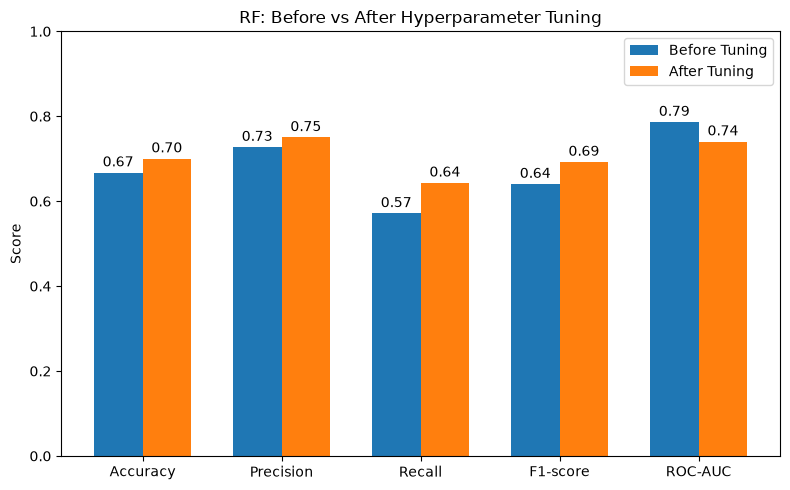

In [7]:
#plotting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Enter your results
# -----------------------------

before = {
    "Accuracy": 0.667,
    "Precision": 0.727,
    "Recall": 0.571,
    "F1-score": 0.640,
    "ROC-AUC": 0.786
}

after = {
    "Accuracy": 0.70,
    "Precision": 0.75,
    "Recall": 0.643,
    "F1-score": 0.692,
    "ROC-AUC": 0.74
}

# Replace the numbers above with your actual values.

# -----------------------------
# Create DataFrame
# -----------------------------

results = pd.DataFrame({
    "Before Tuning": before,
    "After Tuning": after
})

print(results)

# -----------------------------
# Plot
# -----------------------------

fig, ax = plt.subplots(figsize=(8,5))

x = np.arange(len(results.index))
width = 0.35

ax.bar(
    x - width/2,
    results["Before Tuning"],
    width,
    label="Before Tuning"
)

ax.bar(
    x + width/2,
    results["After Tuning"],
    width,
    label="After Tuning"
)

ax.set_xticks(x)
ax.set_xticklabels(results.index)

ax.set_ylabel("Score")
ax.set_ylim(0,1)

ax.set_title("RF: Before vs After Hyperparameter Tuning")

ax.legend()

# Write values on bars
for i, value in enumerate(results["Before Tuning"]):
    ax.text(
        i - width/2,
        value + 0.015,
        f"{value:.2f}",
        ha="center",
        fontsize=10
    )

for i, value in enumerate(results["After Tuning"]):
    ax.text(
        i + width/2,
        value + 0.015,
        f"{value:.2f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
   "../figures/RF10_before_after_tuning.svg",
    dpi=1200,
    bbox_inches="tight"
)

plt.show()